In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Inspection

In [111]:
df = pd.read_excel('../data/raw/default_of_credit_card_clients.xls', header=1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


#### Data Structure

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [113]:
df.shape

(30000, 25)

#### Missing Data

In [114]:
df.isnull().sum().sum()

np.int64(0)

#### Summary Statistics

In [115]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


#### Duplicates

In [116]:
df.duplicated().sum()

np.int64(0)

#### Summary

Dataset contains 30,000 observations and 25 variables. All variables are stored as integer (int64) data types. No missing values or duplicate records were identified, indicating that the dataset is complete and suitable fo further exploratory analysis.

### EDA

#### Target Variable Distribution

The target variable indicates whether a client defaulted on their credit card payment in the following month. A value of 0 represents clients who did not default, while a value of 1 represents clients who defaulted on their payment obligations.

In [117]:
df['default payment next month'].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [118]:
df['default payment next month'].value_counts(normalize=True) * 100

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

Approximately 77.9% of clients did not default on their credit card payment in the following month, while 22.1% defaulted. This indicates that the dataset is moderately imbalanced, with substantially more non-default than default cases.

In [119]:
default_counts = df['default payment next month'].value_counts().sort_index()
default_counts.index = ['No Default', 'Default']

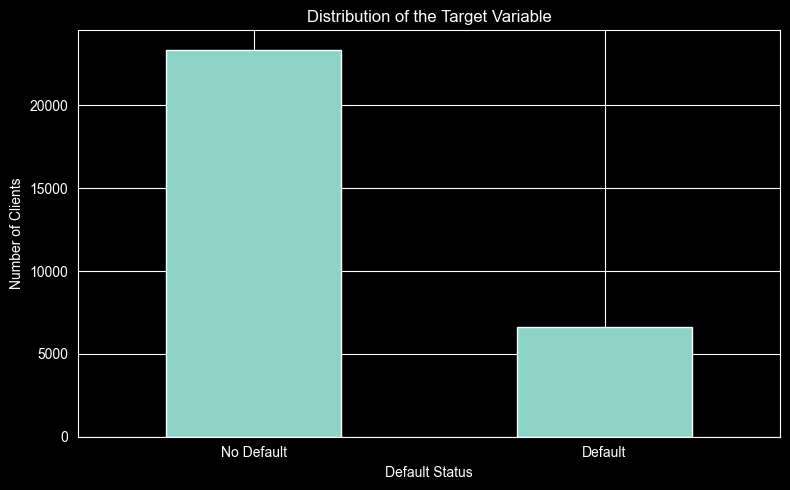

In [120]:
plt.figure(figsize=(8, 5))
default_counts.plot(kind="bar")

plt.title("Distribution of the Target Variable")
plt.xlabel("Default Status")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Numerical Variable Distribution

##### Credit Limit (LIMIT_BAL)

Amount of the given credit (New Taiwan (NT) dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.

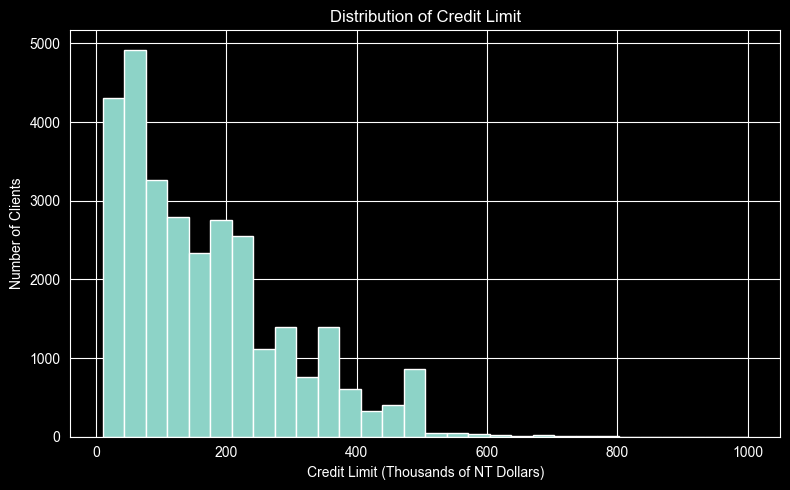

In [121]:
plt.figure(figsize=(8, 5))

plt.hist(df['LIMIT_BAL'] / 1000, bins=30)

plt.title('Distribution of Credit Limit')
plt.xlabel('Credit Limit (Thousands of NT Dollars)')
plt.ylabel('Number of Clients')

plt.tight_layout()
plt.show()

The histogram shows that the distribution of credit limits is positively (right) skewed. Most clients have credit limits below approximately 250 thousand NT dollars, while relatively few clients have substantially higher credit limits. The long right tail indicates that a small number of clients were granted very large credit limits.

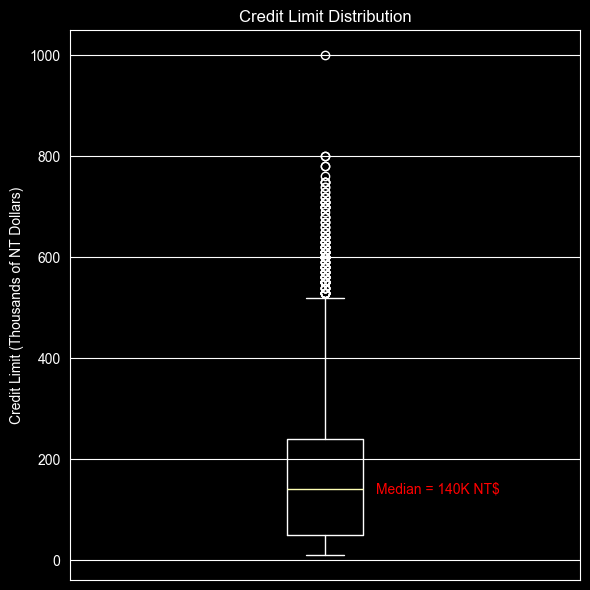

In [122]:
plt.figure(figsize=(6, 6))

plt.boxplot(df['LIMIT_BAL'] / 1000)

plt.title('Credit Limit Distribution')
plt.ylabel('Credit Limit (Thousands of NT Dollars)')
plt.xticks([])

median = df['LIMIT_BAL'].median() / 1000

plt.text(
    1.10,
    median,
    f'Median = {median:.0f}K NT$',
    color='red',
    fontsize=10,
    va='center'
)

plt.tight_layout()
plt.show()

The boxplot indicates that the median credit limit is approximately 140 thousand NT Dollars, while the middle 50% of observations fall between roughly 50 thousand and 240 thousand NT Dollars. Numerous high-value outliers are present, indicating that a relatively small number of clients were assigned substantially larger credit limits than the majority of customers.

##### AGE

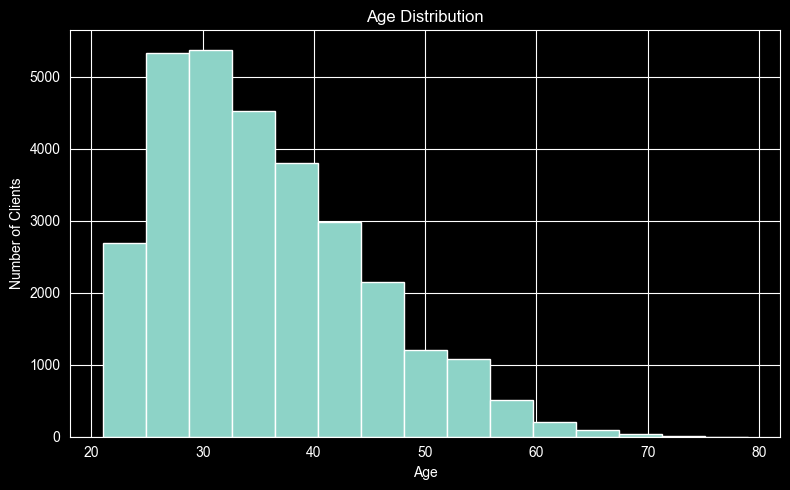

In [123]:
plt.figure(figsize=(8,5))

plt.hist(df['AGE'], bins=15)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Clients')

plt.tight_layout()
plt.show()

The age distribution is moderately right-skewed, with the highest concentration of clients between approximately 25 and 35 years of age. The number of clients gradually decreases as age increases, indicating that older individuals represent a smaller proportion of the dataset.

#### Categorical Variables Distribution

##### SEX

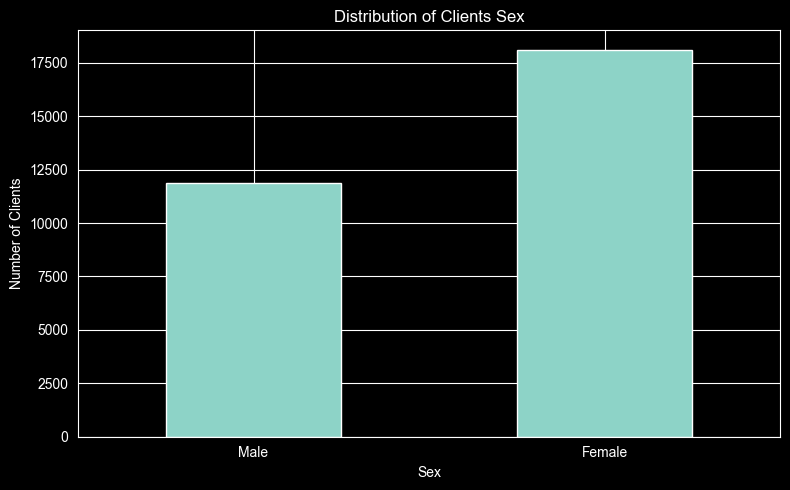

In [124]:
sex_counts = df['SEX'].value_counts().sort_index()
sex_counts.index = ['Male', 'Female']

plt.figure(figsize=(8, 5))
sex_counts.plot(kind="bar")

plt.title('Distribution of Clients Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The dataset contains both male and female clients, with females representing the larger proportion of the sample.

##### EDUCATION

In [125]:
edu_counts = df['EDUCATION'].value_counts().sort_index()
edu_counts

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [126]:
edu_counts.index = ['Unknown (0)', 'Graduate School', 'University', 'High School', 'Other', 'Unknown (5)', 'Unknown (6)']

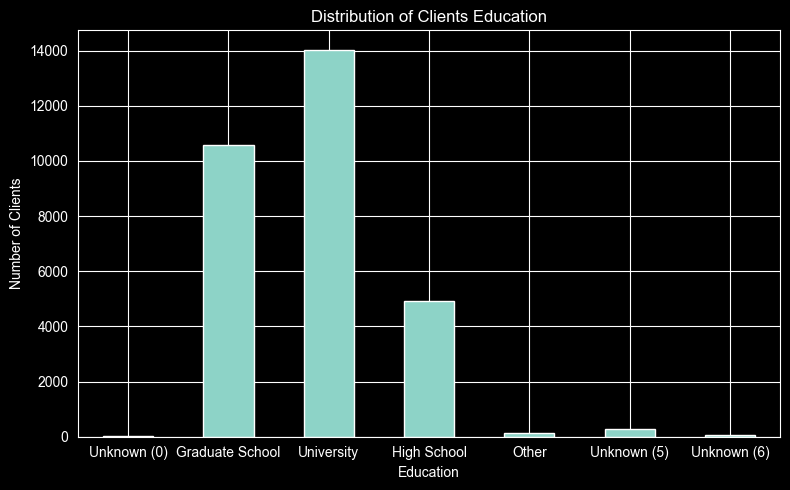

In [127]:
plt.figure(figsize=(8, 5))
edu_counts.plot(kind="bar")

plt.title('Distribution of Clients Education')
plt.xlabel('Education')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

According to the dataset documentation, the EDUCATION variable should contain four categories (graduate school, university, high school, and other). However, exploratory analysis identified three additional undocumented values (0, 5, and 6). These categories account for only 345 observations (1.15% of the dataset) and will be recoded into 'Unknown' category during the preprocessing stage.

##### MARITAL STATUS

In [128]:
mar_counts = df['MARRIAGE'].value_counts().sort_index()
mar_counts

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [129]:
mar_counts.index = ['Unknown', 'Married', 'Single', 'Other']

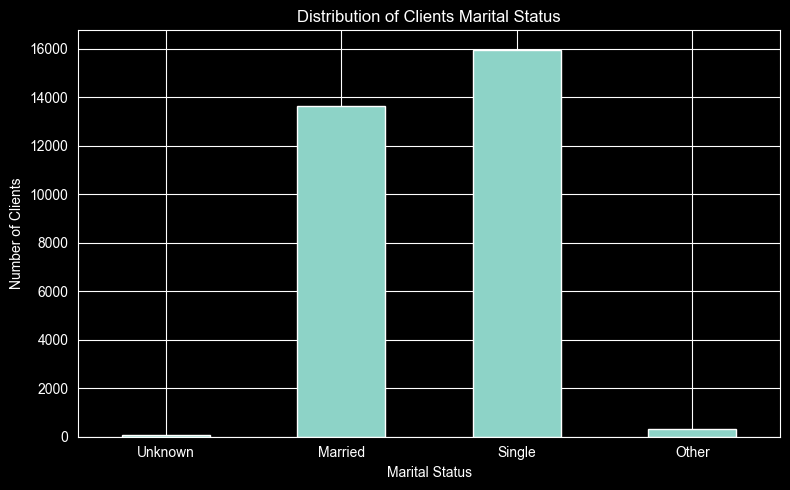

In [130]:
plt.figure(figsize=(8, 5))
mar_counts.plot(kind="bar")

plt.title('Distribution of Clients Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Clients')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The dataset documentation specifies three marital status categories (married, single, and other); however, 54 observations contained an undocumented value of 0, which will be treated as an unknown category during preprocessing.

##### Correlation Heatmap

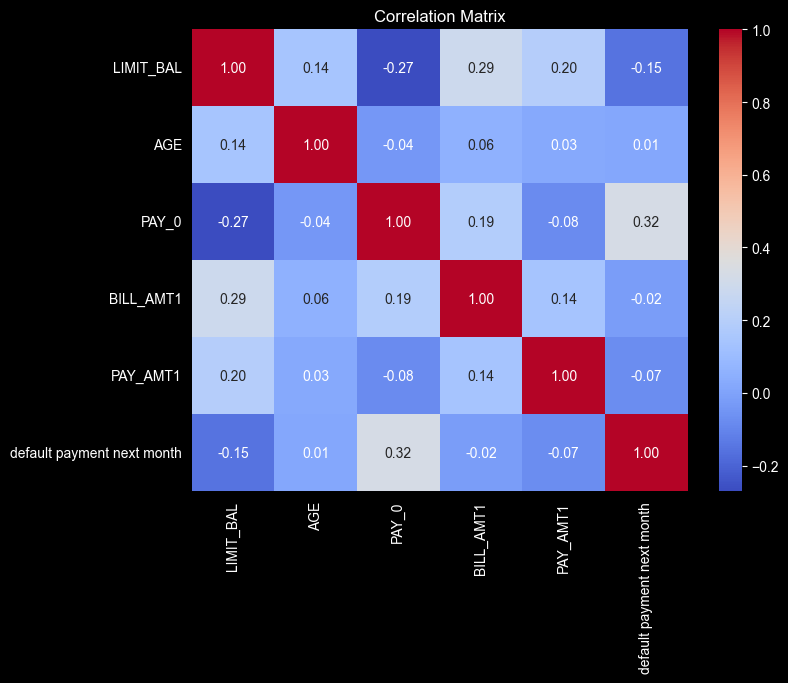

In [136]:
corr_var = df[[
    'LIMIT_BAL',
    'AGE',
    'PAY_0',
    'BILL_AMT1',
    'PAY_AMT1',
    'default payment next month'
]]
corr_matrix = corr_var.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",)
plt.title("Correlation Matrix")

plt.show()